C:\Users\Admin\anaconda3\Lib\site-packages\pyogrio\geopandas.py:346: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["geometry"] = shapely.from_wkb(wkb_values, on_invalid=on_invalid)


 summary:
count    535.00
mean       3.79
std        4.59
min        0.30
25%        1.70
50%        2.30
75%        3.80
max       48.40
Name: as_ppm, dtype: float64
 Median 2.30
Skewness 4.66
10.659999999999991
Hotspot threshold (95th percentile): 10.66 ppm
Number of hotspot samples: 27


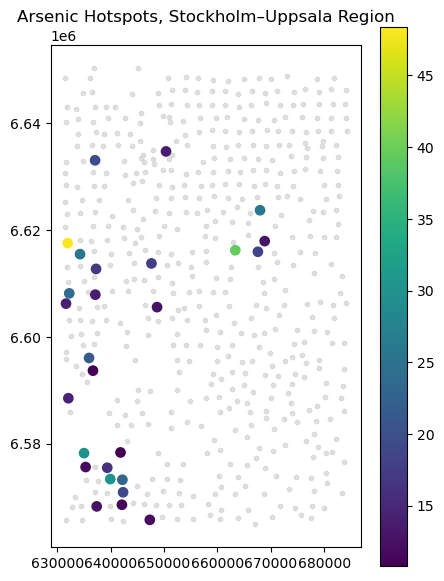

In [16]:
import geopandas as gpd
from pyproj import Transformer
import matplotlib.pyplot as plt

# Read raw data (_icpms) and save cleaned data
gpd.options.io_engine = "pyogrio" #by default it will be applied to read_file
markgeokemi_icpms = gpd.read_file(
    "C:/Projects/markgeokemi/raw_data/markgeokemi_regional.gpkg",
    layer = "moran_0063mm_hno3_icpms",
    use_arrow = True
).dropna(subset=["unikt_id", "ns", "ew", "geometry"]
).set_crs("EPSG:3006", allow_override=True) #remove NaN
#markgeokemi_icpms_clean = markgeokemi_icpms.copy()
markgeokemi_icpms.to_file(
     "C:/Projects/markgeokemi/cleaned_data/markgeokemi_icpms_clean.gpkg",
    driver= "GPKG",
    use_arrow = True) #save in cleaned raw_data
markgeokemi_icpms_clean.to_file(
    "C:/Projects/markgeokemi/cleaned_data/markgeokemi_icpms_clean.gpkg",
    driver="GPKG",
    use_arrow=True
)

# Geographic bbox in WGS84
min_lat, max_lat = 59.20, 59.95
min_lon, max_lon = 17.30, 18.30
trans = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3006",
    always_xy = True
)
# Convert bbox corners
min_ew, min_ns = trans.transform(min_lon, min_lat)  # lower-left
max_ew, max_ns = trans.transform(max_lon, max_lat)  # upper-right
#print(f"min_ew={min_ew}, max_ew={max_ew}")
#print(f"min_ns={min_ns}, max_ns={max_ns}")
    
as_stoch_upp = markgeokemi_icpms_clean[
    (markgeokemi_icpms_clean["as_ppm"].notna()) &
    (markgeokemi_icpms_clean["as_ppm"] > 0) &
    (markgeokemi_icpms_clean["ew"].between(min_ew, max_ew)) &
    (markgeokemi_icpms_clean["ns"].between(min_ns, max_ns))
][["unikt_id", "ns", "ew", "as_ppm", "geometry"]] #filter rows based on a condition that values in column as_ppm >0

#summary stats
as_stoch_upp_stat = as_stoch_upp["as_ppm"].describe()
median_as_stoch_upp = as_stoch_upp["as_ppm"].median()
skew_as_stoch_upp = as_stoch_upp["as_ppm"].skew()

print(f" summary:")
print(as_stoch_upp_stat.round(2))
print(f" Median {median_as_stoch_upp:.2f}")
print(f"Skewness {skew_as_stoch_upp:.2f}")

#print(as_icpms.describe())
thresh_95 = as_stoch_upp["as_ppm"].quantile(0.95)
print(thresh_95)
as_stoch_upp_hotspots = as_stoch_upp[
    as_stoch_upp["as_ppm"] >= thresh_95
]

print(f"Hotspot threshold (95th percentile): {thresh_95:.2f} ppm")
print(f"Number of hotspot samples: {len(as_stoch_upp_hotspots)}")

fig, ax = plt.subplots(figsize=(5, 7))

as_stoch_upp.plot(
    ax=ax,
    color="lightgrey",
    markersize=10,
    alpha=0.7
)

as_stoch_upp_hotspots.plot(
    column="as_ppm",
    legend=True,
    ax=ax,
    markersize=45
)
ax.set_title("Arsenic Hotspots, Stockholm–Uppsala Region")
plt.savefig(
    "C:/Projects/markgeokemi/results/as_stockholm_Uppsala_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
